# UFC Elo Analysis

This notebook loads `db/historical_elo_snapshots.csv` (generated by `elo_engine.py`) and visualizes how fighter ratings evolve over time.

- **P4P timeline**: top pound-for-pound fighters by peak rating
- **Divisional timeline**: top fighters in a selected weight class

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.facecolor": "#111111",
    "figure.facecolor": "#111111",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "#444444",
    "grid.color": "#333333",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#444444",
})

DATA_PATH = Path("db/historical_elo_snapshots.csv")
snapshots = pd.read_csv(DATA_PATH, parse_dates=["date"])
snapshots["elo_score"] = pd.to_numeric(snapshots["elo_score"], errors="coerce")
snapshots = snapshots.dropna(subset=["elo_score", "fighter_id", "weight_class"])

print(f"Loaded {len(snapshots):,} rows spanning {snapshots['date'].min().date()} to {snapshots['date'].max().date()}")

Loaded 215,530 rows spanning 1994-03-01 to 2026-06-01


In [7]:
def top_fighters_by_peak(df: pd.DataFrame, weight_class: str, n: int = 10) -> list[str]:
    """Return fighter IDs with the highest peak Elo in a weight class."""
    class_df = df[df["weight_class"] == weight_class].copy()
    if class_df.empty:
        return []

    peaks = (
        class_df.groupby("fighter_id", as_index=False)
        .agg(peak_elo=("elo_score", "max"), fighter_name=("fighter_name", "last"))
        .sort_values("peak_elo", ascending=False)
    )
    return peaks.head(n)["fighter_id"].tolist()


def plot_elo_timeline(
    df: pd.DataFrame,
    weight_class: str,
    top_n: int = 10,
    title: str | None = None,
) -> None:
    """Plot multi-line Elo timelines for the top fighters by peak rating."""
    top_ids = top_fighters_by_peak(df, weight_class=weight_class, n=top_n)
    if not top_ids:
        print(f"No data available for weight class '{weight_class}'.")
        return

    plot_df = df[
        (df["weight_class"] == weight_class) & (df["fighter_id"].isin(top_ids))
    ].copy()

    name_map = (
        plot_df.groupby("fighter_id")["fighter_name"].last().to_dict()
    )
    plot_df["label"] = plot_df["fighter_id"].map(name_map)

    palette = sns.color_palette("husl", n_colors=len(top_ids))
    fig, ax = plt.subplots()

    for color, fighter_id in zip(palette, top_ids):
        fighter_df = plot_df[plot_df["fighter_id"] == fighter_id].sort_values("date")
        ax.plot(
            fighter_df["date"],
            fighter_df["elo_score"],
            label=name_map.get(fighter_id, fighter_id),
            linewidth=2.4,
            color=color,
        )

    ax.set_title(title or f"Top {top_n} Fighters — {weight_class.upper()}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Elo Rating")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## Pound-for-Pound Timeline

Shows the historical Elo paths for fighters with the highest **peak** P4P ratings. Adjust `top_n` to plot the top 10 or top 20.

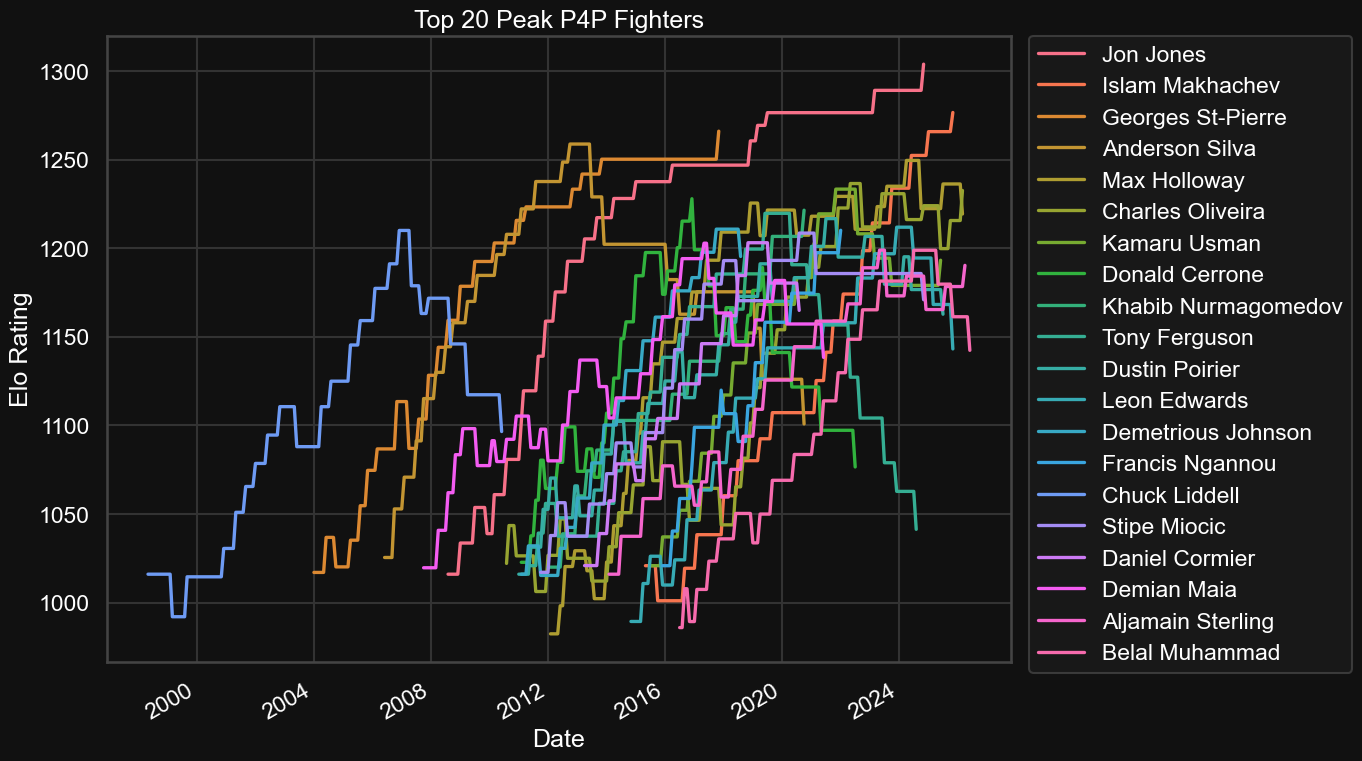

In [8]:
top_n = 20  # change to 10 for a tighter chart
plot_elo_timeline(snapshots, weight_class="p4p", top_n=top_n, title=f"Top {top_n} Peak P4P Fighters")

## Divisional Timeline

Change `target_division` to explore any tracked division (`lw`, `ww`, `mw`, `hw`, `bw`, `fw`, `flw`, `lhw`, `wsw`, etc.).

Available divisions: bw, catch, flw, fw, hw, lhw, lw, mw, open weight, ufc 10 tournament title bout, ufc 2 tournament title bout, ufc 3 tournament title bout, ufc 4 tournament title bout, ufc 5 tournament title bout, ufc 6 tournament title bout, ufc 7 tournament title bout, ufc 8 tournament title bout, ufc superfight championship bout, ultimate ultimate '95 tournament title bout, ultimate ultimate '96 tournament title bout, wbw, wflw, wfw, wsw, ww


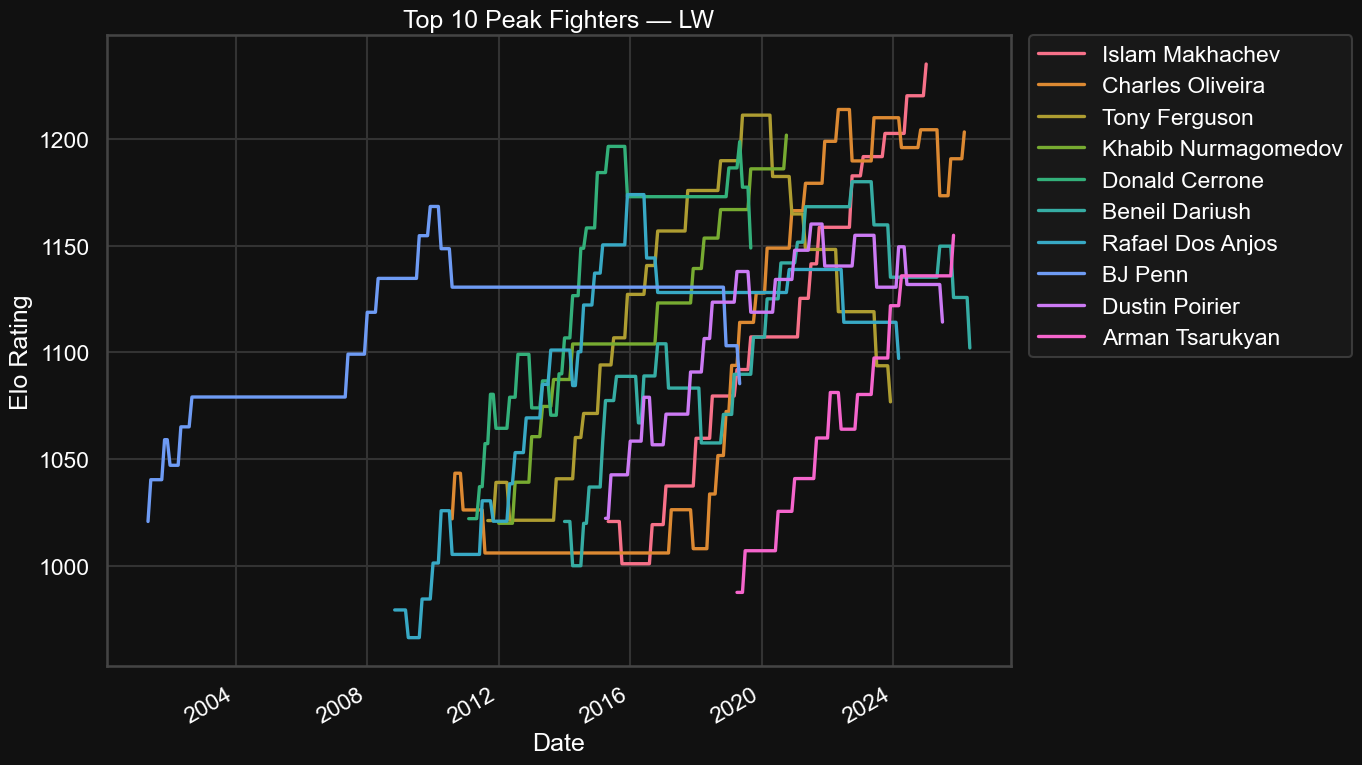

In [9]:
target_division = "lw"
division_top_n = 10

available_divisions = sorted(
    d for d in snapshots["weight_class"].unique() if d != "p4p"
)
print("Available divisions:", ", ".join(available_divisions))

plot_elo_timeline(
    snapshots,
    weight_class=target_division,
    top_n=division_top_n,
    title=f"Top {division_top_n} Peak Fighters — {target_division.upper()}",
)

## Divisions Below Lightweight

Historical timelines for every weight class lighter than lightweight (`fw`, `bw`, `flw`, and women's divisions).

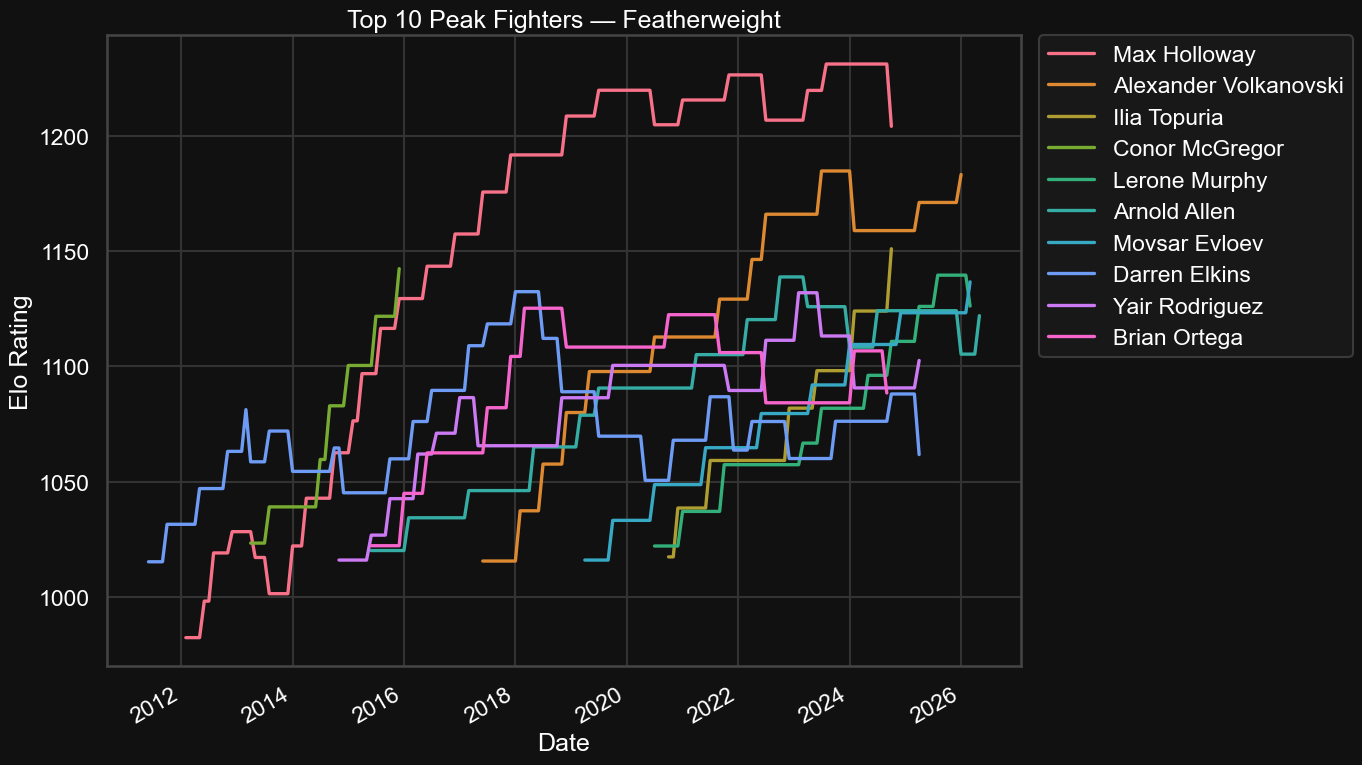

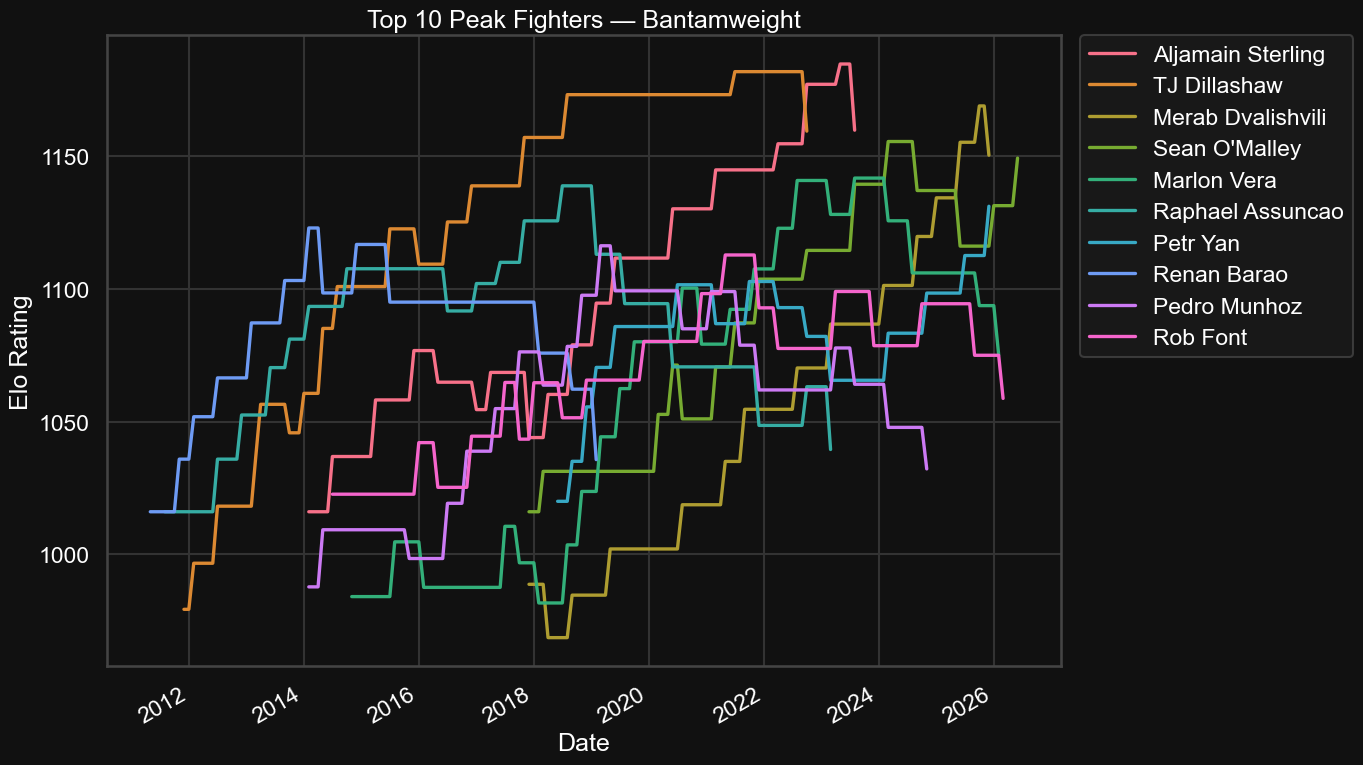

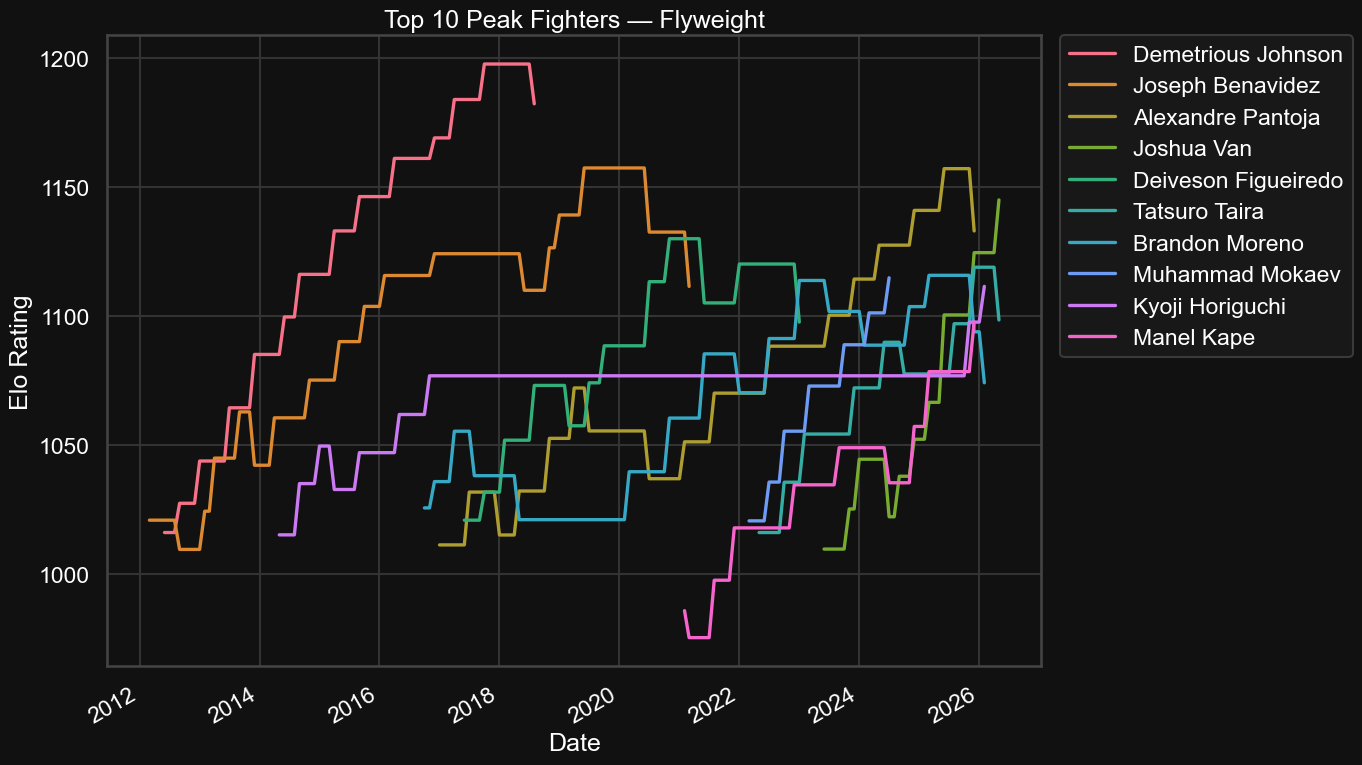

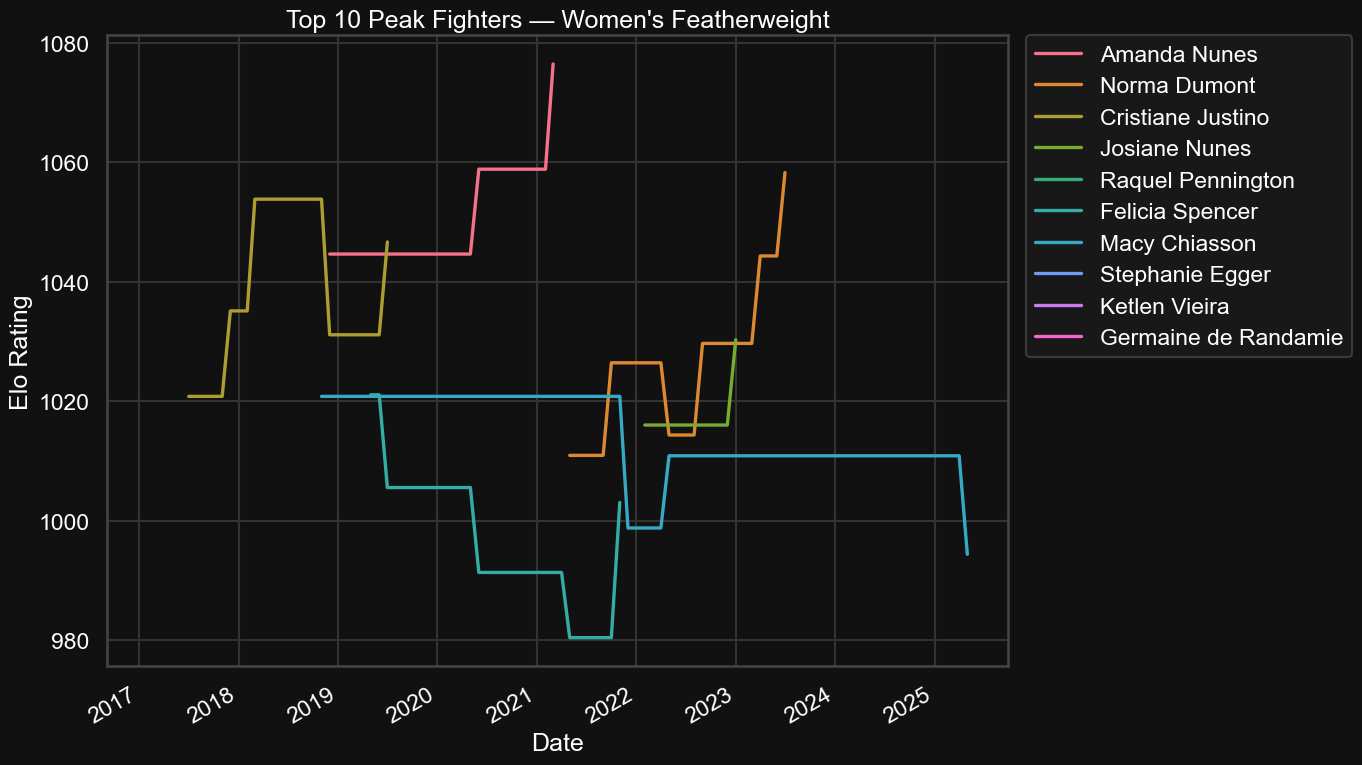

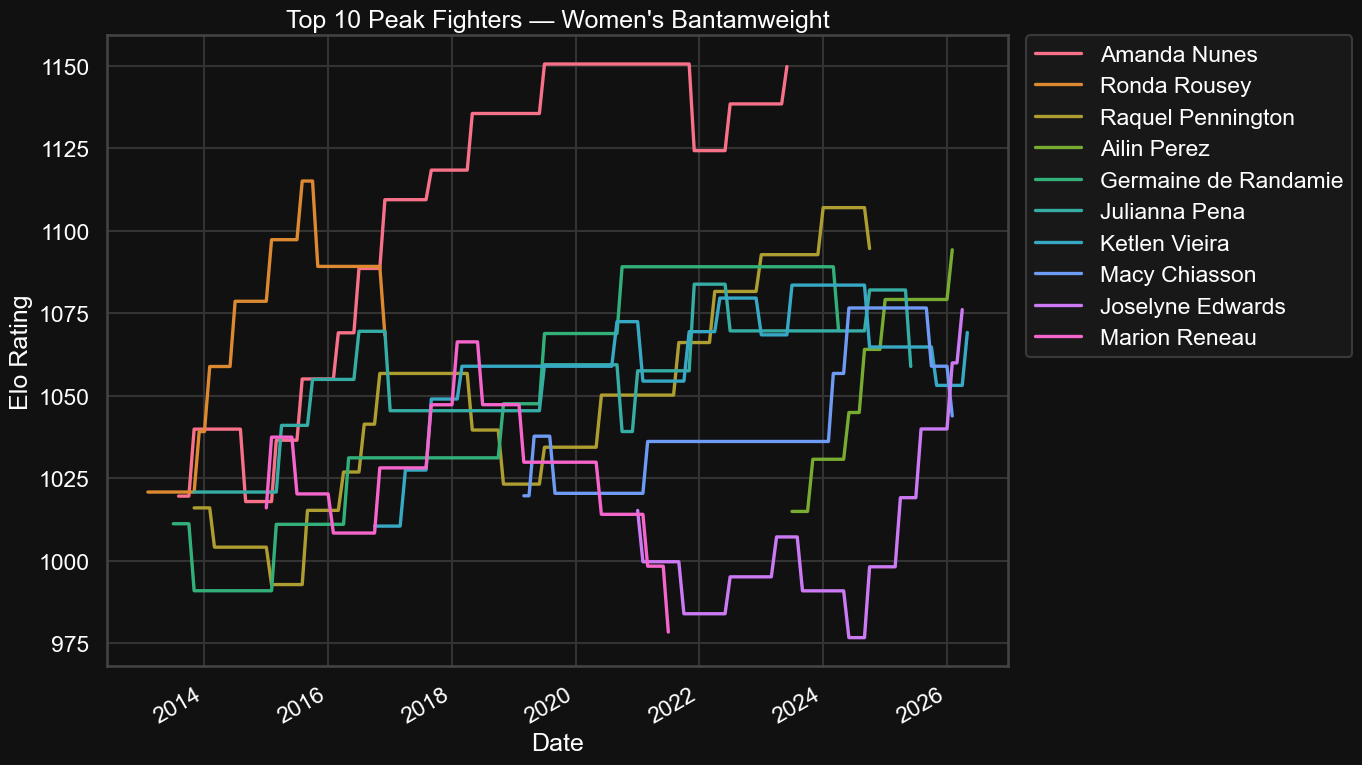

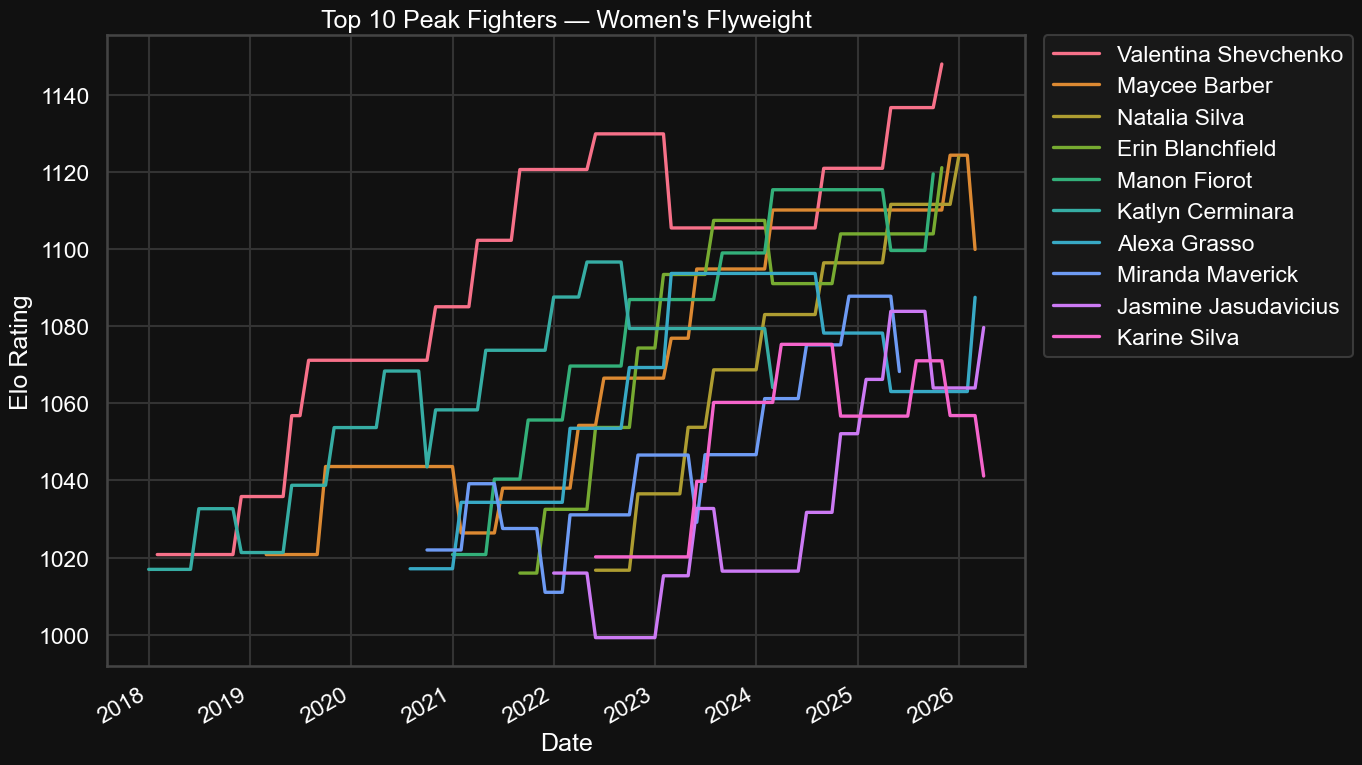

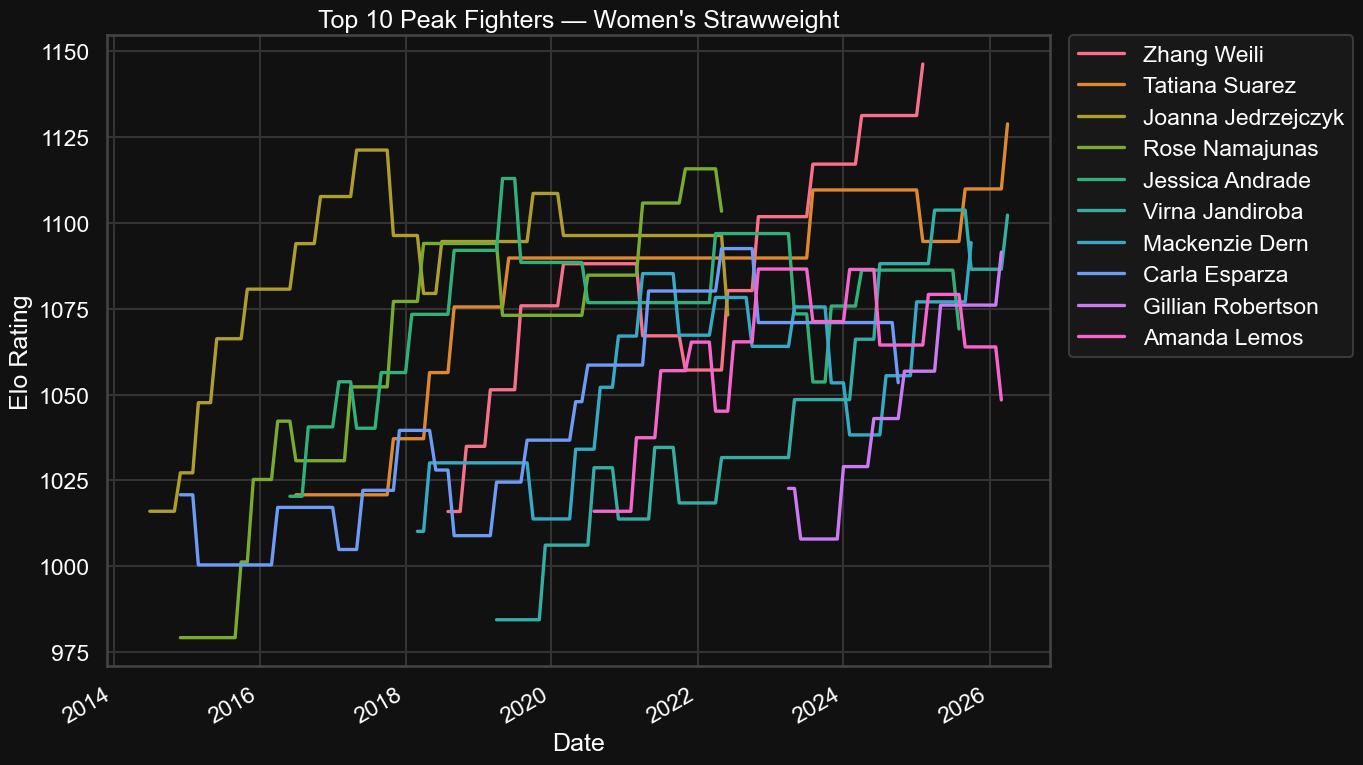

In [10]:
division_top_n = 10

below_lw_divisions = [
    ("fw", "Featherweight"),
    ("bw", "Bantamweight"),
    ("flw", "Flyweight"),
    ("wfw", "Women's Featherweight"),
    ("wbw", "Women's Bantamweight"),
    ("wflw", "Women's Flyweight"),
    ("wsw", "Women's Strawweight"),
]

for division_code, division_label in below_lw_divisions:
    plot_elo_timeline(
        snapshots,
        weight_class=division_code,
        top_n=division_top_n,
        title=f"Top {division_top_n} Peak Fighters — {division_label}",
    )

## Divisions Above Lightweight

Historical timelines for welterweight, middleweight, light heavyweight, and heavyweight.

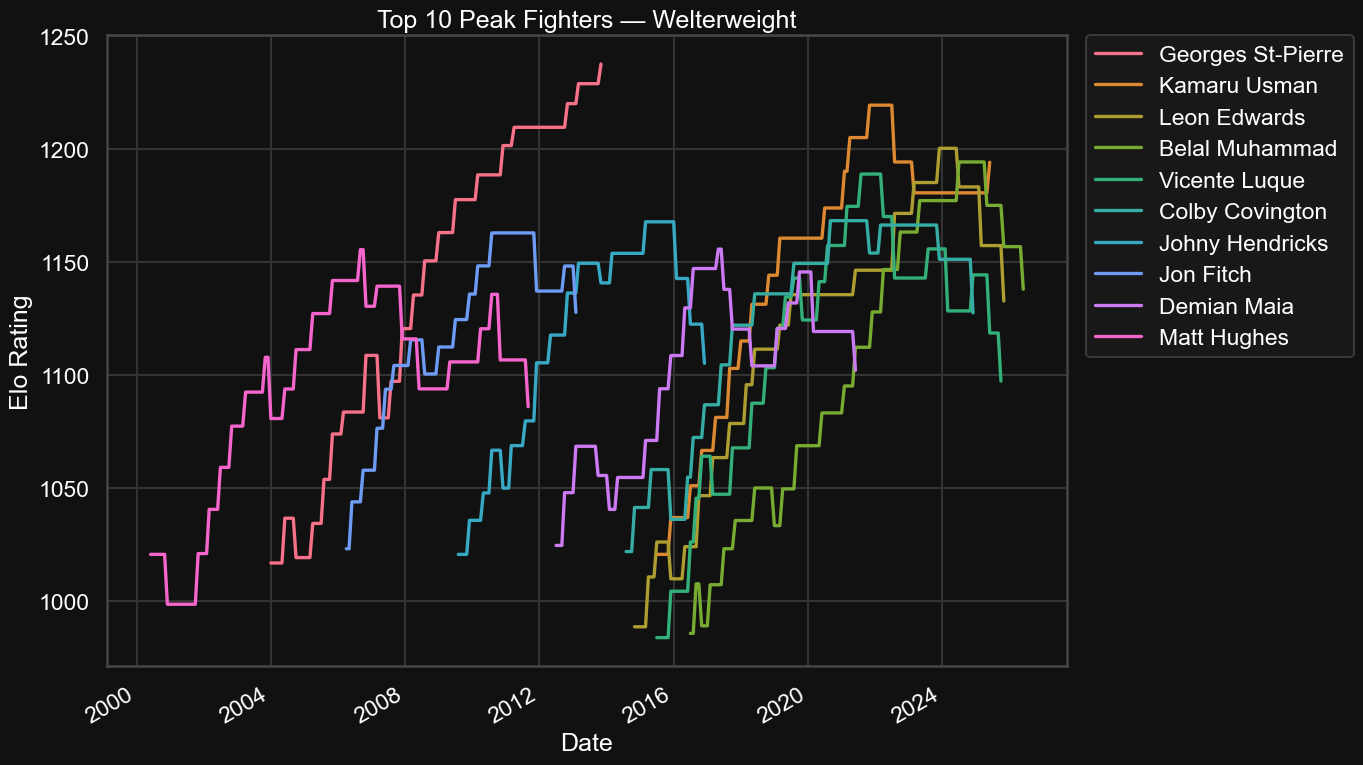

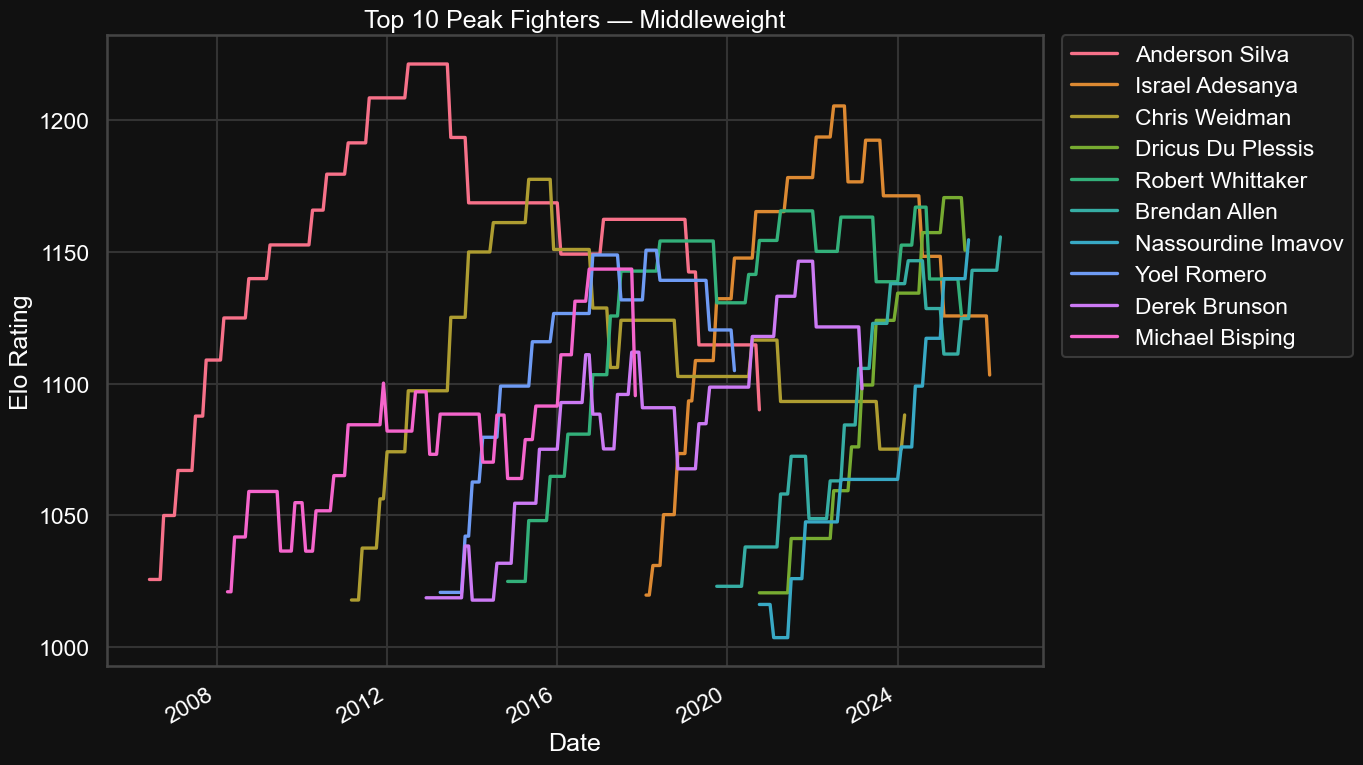

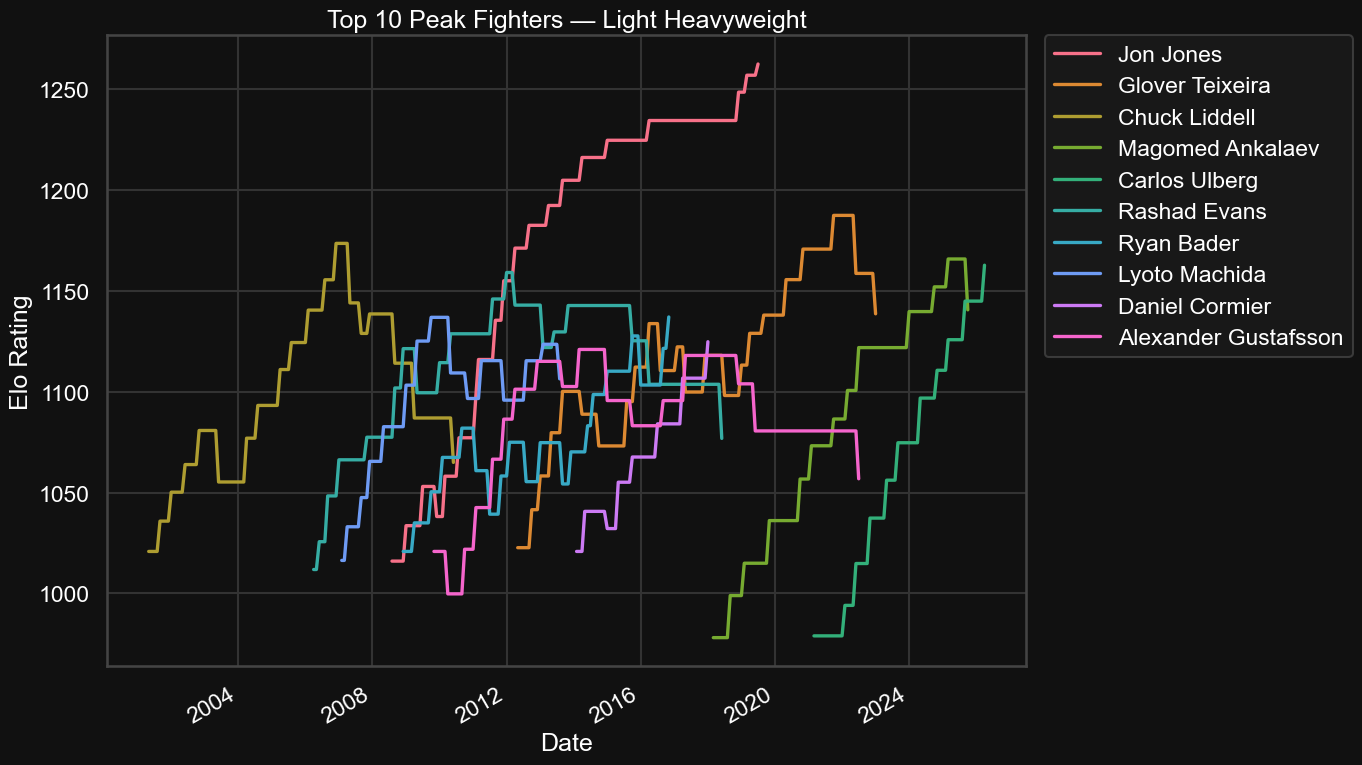

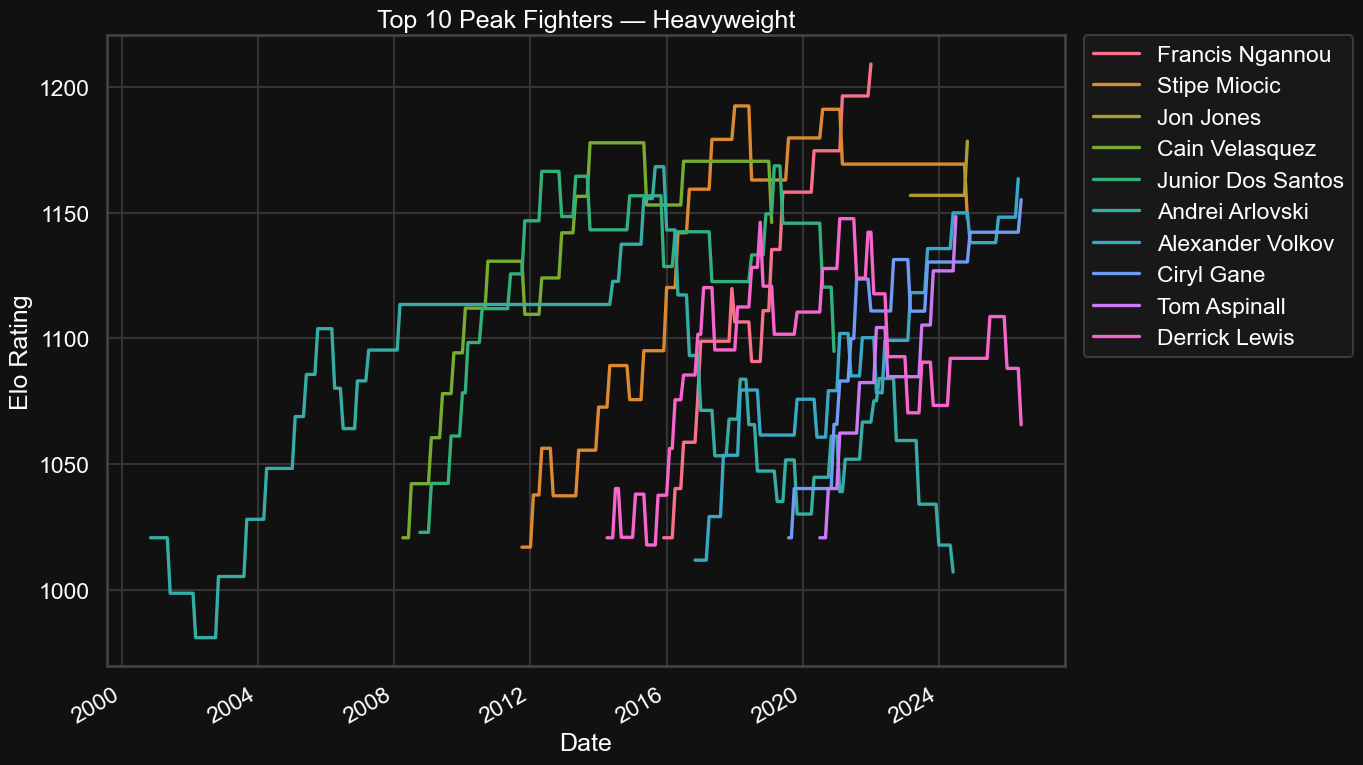

In [11]:
division_top_n = 10

above_lw_divisions = [
    ("ww", "Welterweight"),
    ("mw", "Middleweight"),
    ("lhw", "Light Heavyweight"),
    ("hw", "Heavyweight"),
]

for division_code, division_label in above_lw_divisions:
    plot_elo_timeline(
        snapshots,
        weight_class=division_code,
        top_n=division_top_n,
        title=f"Top {division_top_n} Peak Fighters — {division_label}",
    )